<a href="https://colab.research.google.com/github/CeZa18/jupyter-exploration/blob/main/Lab_06_CesarZaldivar_ITAI_1378_Detection_and_Segmentation_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 06: Object Detection and Image Segmentation

**ITAI 1378  |  Module 06 Companion Lab  |  2026**

**Author:** Patricia McManus     **Collaborator:** Claude (Anthropic)

**Course:** AI and Robotics Program, Digital and Information Technology Center of Excellence, Houston City College

---

In this lab you will work with two of the most useful and most asked-about computer vision tasks: **object detection** (drawing boxes around things) and **image segmentation** (outlining each thing exactly). You will use modern 2026 tools that real CV engineers use every day. You will also see how a specialized detector compares to a foundation model.

This is the lab where the **midterm project gets introduced**, so plan to leave time at the end to start thinking about what you want to build.

## What you will be able to do by the end of this lab

By the end of this lab you will be able to:

- Explain how classification, detection, and segmentation differ.
- Run a modern object detector on any image and read its output.
- Run an instance segmenter and visualize the masks it produces.
- Compare a specialist detector (YOLO11) with a foundation model (SAM 2).
- Talk about evaluation metrics (IoU, precision, recall, mAP) in plain English.
- Pick a midterm project direction that uses the techniques from Modules 1 through 6.

## What you will NOT have to do

- Implement any math from scratch.
- Train a model from zero (we use pretrained weights throughout).
- Use anything outside a free Google Colab account.

If you can copy code into a cell and press Run, you can do this lab.

---

## 1.  The Three CV Tasks Side by Side

Before we touch any code, let's make sure the three core CV tasks are clear in your head. Every CV system you will ever encounter is some variation on these three.

**Image Classification** answers the question: *what is in this image?*

The output is one label for the whole image. For example: this is a picture of a cat. No location, no count, no shape.

**Object Detection** answers: *what is in this image, and where is each thing?*

The output is a list of labeled rectangles, called bounding boxes. For example: cat at the upper left, dog at the lower right. You get the type and the approximate location of each object.

**Image Segmentation** answers: *which exact pixels belong to each thing?*

The output is a pixel-level mask for each object. For example: these 4,521 pixels are the cat, those 8,832 pixels are the dog. You get the precise outline, not just a rectangle.

### Which task is right for which job?

- **Classification:** Sorting a photo library by category. Detecting whether a product image has a logo or not.
- **Detection:** Counting cars in a parking lot. Spotting a person in a hazard zone. Reading license plates.
- **Segmentation:** Medical imaging where exact organ outlines matter. Background removal for video calls. Robot arms that need to grasp specific objects.

Today we focus on detection and segmentation. Module 5 already covered classification.

---

## 2.  Setup

We will use the **Ultralytics** library, which is the standard 2026 toolkit for working with YOLO detection and segmentation models. It also wraps Meta's SAM 2 foundation model, so we get both worlds with one library install.

Run the cell below to install Ultralytics. The first time this runs in a fresh Colab notebook it will take about a minute.

In [1]:
# Install the Ultralytics library
# This gives us YOLO11 (detection and segmentation) and SAM 2 (foundation model) in one package.
%pip install -q ultralytics

# Quick check that everything imported successfully
from ultralytics import YOLO, SAM
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

print("Setup complete. Ready to detect and segment.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 5.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Setup complete. Ready to detect and segment.


---

## 3.  Load a Sample Image

Ultralytics ships with a few sample images we can use without uploading anything ourselves. We will start with one that contains several common objects (people, a bus, etc.) so the detector and segmenter have something interesting to find.

You can also upload your own image to Colab later by clicking the folder icon in the left sidebar and dragging a file in.

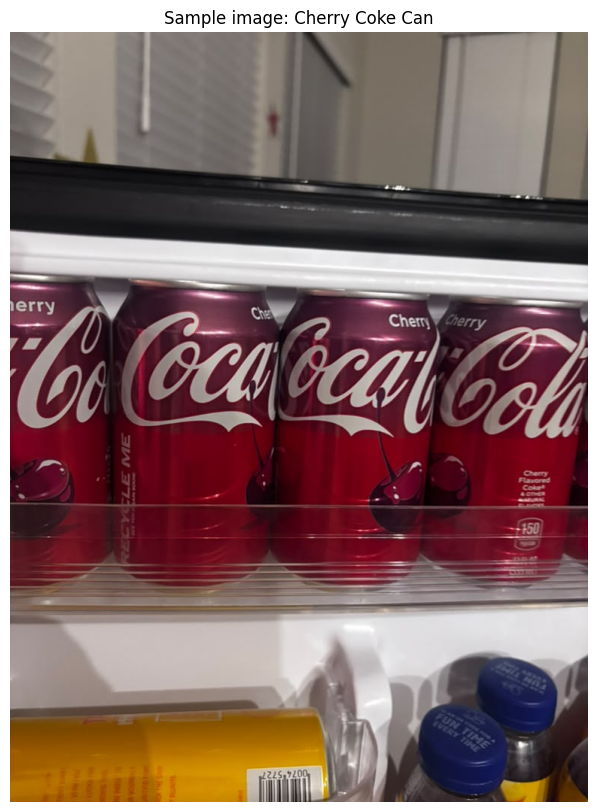

Image size: 768 wide by 1024 tall pixels


In [3]:
import os

# This is a sample image that ships with the Ultralytics package
# SAMPLE_IMAGE = "https://ultralytics.com/images/bus.jpg"
SAMPLE_IMAGE = "/content/personal_sample_data/cherry_coke_can.jpeg"

# Display it so we know what we're working with
# Check if the image exists at the specified path
if not os.path.exists(SAMPLE_IMAGE):
    print(f"Error: Image not found at {SAMPLE_IMAGE}")
else:
    img = Image.open(SAMPLE_IMAGE)
    plt.figure(figsize=(8, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Sample image: Cherry Coke Can")
    plt.show()

    print(f"Image size: {img.size[0]} wide by {img.size[1]} tall pixels")

---

## 4.  Object Detection with YOLO11

YOLO11 is the current production-default real-time object detector from Ultralytics, released in September 2024 and still recommended for most workforce use cases in 2026. It is a *specialist* model: it was trained specifically to find and box 80 common object categories like person, car, dog, traffic light, and so on (the COCO dataset categories).

### Why YOLO

The YOLO family is popular because it is:
- **Fast.** Many YOLO variants run in real time, even on a laptop.
- **Accurate enough for most jobs.** Good general purpose performance on common objects.
- **Easy to use.** Two lines of code to load and run.
- **Available in many sizes.** Pick a tiny version for an edge device, or a large version for a workstation.

### Loading the model

We will use **yolo11n**, the smallest "nano" version. Small enough to run on free Colab, fast enough to demo live.

In [4]:
# Load a pretrained YOLO11 nano model
# The first run downloads the weights automatically (about 5 MB).
detector = YOLO("yolo11n.pt")

print("YOLO11 nano loaded.")
print(f"Number of object classes it knows: {len(detector.names)}")
print(f"First ten classes: {list(detector.names.values())[:10]}")

YOLO11 nano loaded.
Number of object classes it knows: 80
First ten classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


### Running detection

Detection is now just one line. The model takes an image and returns a results object with boxes, labels, and confidence scores.

In [ ]:
# Run detection on the sample image
results = detector(SAMPLE_IMAGE)

# The results object has built-in visualization
# results[0].plot() returns an annotated image as a numpy array (in BGR format)
annotated = results[0].plot()

# Convert BGR (OpenCV style) to RGB (Matplotlib style) for display
annotated_rgb = annotated[..., ::-1]

plt.figure(figsize=(10, 12))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("YOLO11 detection results")
plt.show()

### Reading the output

The results object also gives us the raw information so we can do our own analysis. Let's see what the model actually found.

In [ ]:
# Print a summary of what the detector found
print("DETECTED OBJECTS")
print("=" * 50)

# results[0].boxes has the detection details
boxes = results[0].boxes

# Loop through each detected object
for i in range(len(boxes)):
    class_id = int(boxes.cls[i])
    class_name = detector.names[class_id]
    confidence = float(boxes.conf[i])
    # xyxy gives [x_min, y_min, x_max, y_max] in pixel coordinates
    x_min, y_min, x_max, y_max = boxes.xyxy[i].tolist()

    print(f"  {class_name:<15} confidence: {confidence:.2%}    "
          f"box: ({int(x_min)}, {int(y_min)}) to ({int(x_max)}, {int(y_max)})")

print(f"\nTotal objects detected: {len(boxes)}")

---

### Your Turn 1: Try It on a Different Image

Run the detector on a different image and see what it finds. You have two options:

**Option A:** Use another Ultralytics sample image. Try one of these URLs by changing `my_image` below:
- `https://ultralytics.com/images/zidane.jpg`  (two people on a soccer field)
- `https://ultralytics.com/images/bus.jpg`  (the one we already saw)

**Option B:** Upload your own image. Click the folder icon in the left Colab sidebar, drag in a JPG or PNG, then set `my_image` to its filename (something like `"/content/my_photo.jpg"`).

**What to do:**
1. Set `my_image` to your chosen URL or filename.
2. Run the cell.
3. Look at the output and answer: did the model find what you expected? Was anything missed or wrong?

In [ ]:
# Change this to your image URL or uploaded file path
my_image = "https://ultralytics.com/images/zidane.jpg"

# Run detection
my_results = detector(my_image)
annotated = my_results[0].plot()[..., ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Your image with YOLO11 detections")
plt.show()

# Show what was detected
print("Detected:")
for i in range(len(my_results[0].boxes)):
    name = detector.names[int(my_results[0].boxes.cls[i])]
    conf = float(my_results[0].boxes.conf[i])
    print(f"  {name} ({conf:.0%})")

---

### Experiment: Confidence Threshold

Every detection comes with a confidence score from 0 to 1. By default, YOLO11 only shows detections with confidence above about 0.25. You can change this threshold.

**Lower threshold** (say 0.10): more detections, including more wrong ones.

**Higher threshold** (say 0.70): fewer detections, but the ones you keep are more likely to be right.

This is a real trade-off you will make in production work. A workplace safety system that watches for people in hazard zones might want a LOW threshold (better to false-alarm than miss someone). A consumer photo tagger might want a HIGH threshold (better to miss a few than to mis-tag a lot).

In [ ]:
# Try detection at three different confidence thresholds
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, threshold in zip(axes, [0.10, 0.25, 0.70]):
    r = detector(SAMPLE_IMAGE, conf=threshold, verbose=False)
    ax.imshow(r[0].plot()[..., ::-1])
    ax.axis("off")
    ax.set_title(f"Threshold = {threshold}    "
                 f"({len(r[0].boxes)} detections)")

plt.tight_layout()
plt.show()

print("Notice how the number of detections changes with the threshold.")
print("Which threshold would you pick for a workplace safety alert? For a photo tagger?")

---

### Quick Note: Non-Maximum Suppression (NMS)

You may have noticed that YOLO does not give you forty overlapping boxes around the same bus. That is because of **Non-Maximum Suppression**, abbreviated NMS. It is a cleanup step that runs after the model produces its raw guesses.

**In plain English:** NMS looks at all the boxes the model produced, finds groups of boxes that overlap heavily and have the same label, and keeps only the highest-confidence box from each group. The rest get suppressed (deleted).

You do not have to implement NMS yourself. YOLO does it automatically. But knowing what NMS is matters in interviews, because every detection system has one. Some newer models, like YOLO26 released in January 2026, are "NMS-free" by design, but most detectors you will encounter still use it.

---

## 5.  Instance Segmentation with YOLO11-seg

Now we step up from boxes to exact pixel outlines. **Instance segmentation** is the task of producing a pixel-level mask for each individual object, not just a rectangle.

Why this matters:
- A box around a person tells you *where roughly* the person is. A mask tells you *exactly which pixels* are the person, which is what a video editor or a robot arm needs.
- Boxes always include some background. Masks do not.
- Boxes cannot distinguish two overlapping objects very well. Masks can.

Ultralytics has a segmentation version of YOLO11 called **yolo11n-seg**. It outputs both boxes and masks. Loading and running is the same pattern.

In [ ]:
# Load the YOLO11 nano segmentation model
segmenter = YOLO("yolo11n-seg.pt")

# Run it on the same sample image
seg_results = segmenter(SAMPLE_IMAGE)

# Visualize with built-in plotting
annotated = seg_results[0].plot()[..., ::-1]

plt.figure(figsize=(10, 12))
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLO11-seg: each object gets its own pixel mask")
plt.show()

### Reading segmentation output

A segmentation result has both `boxes` (same as detection) AND `masks` (the new part). Each mask is a binary image the same size as the input: 1 where the object is, 0 where it is not.

In [ ]:
# Show information about the masks
masks = seg_results[0].masks

if masks is not None:
    print(f"Number of objects with masks: {len(masks)}")
    print(f"Each mask shape: {masks.data[0].shape}    "
          "(this is height x width, one pixel per cell)")
    print()

    # Show the first mask on its own so the shape is visible
    first_mask = masks.data[0].cpu().numpy()
    first_label = segmenter.names[int(seg_results[0].boxes.cls[0])]

    plt.figure(figsize=(8, 10))
    plt.imshow(first_mask, cmap="gray")
    plt.axis("off")
    plt.title(f"Just the mask for the first object: {first_label}")
    plt.show()
else:
    print("No masks produced for this image.")

---

### Detection Versus Segmentation Side by Side

Let's put the two results next to each other so the difference is visual and obvious.

In [ ]:
# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(results[0].plot()[..., ::-1])
axes[0].axis("off")
axes[0].set_title("Detection: boxes only")

axes[1].imshow(seg_results[0].plot()[..., ::-1])
axes[1].axis("off")
axes[1].set_title("Segmentation: pixel-level masks")

plt.tight_layout()
plt.show()

print("Same image, two different levels of detail.")
print("Detection is faster. Segmentation gives more precise outlines.")

---

### Your Turn 2: Segment Your Image

Run YOLO11-seg on the same image you used in Your Turn 1.

**What to look for:**
- Are the masks tight to the objects, or do they bleed into the background?
- Do overlapping objects get separated cleanly?
- Are there any pixels obviously assigned to the wrong object?

The answers tell you something about where this specialist model is strong and where it has limits.

In [ ]:
# Use your image from Your Turn 1
# my_image was set earlier; change it again if you want a different one

my_seg_results = segmenter(my_image)
annotated = my_seg_results[0].plot()[..., ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Your image with YOLO11-seg masks")
plt.show()

# How tight are the masks?
masks = my_seg_results[0].masks
if masks is not None:
    print(f"YOLO11-seg produced {len(masks)} masks.")
    print("Look at the visualization above and judge:")
    print("  • Are the masks tight around the objects, or sloppy?")
    print("  • Did any objects get missed?")

---

## 6.  Foundation Models for Segmentation: SAM 2

YOLO11-seg is a **specialist**. It was trained to recognize 80 specific COCO categories and to segment those. If you point it at a teapot, a brain MRI scan, or a satellite image, the categories it knows do not apply and the masks may look strange.

**Segment Anything Model 2** (SAM 2) from Meta is a different beast: it is a **foundation model** for segmentation. It does not know category labels at all. Instead, you point at something with a click, a box, or a prompt, and SAM 2 produces a mask for that thing, whatever it is.

This is a fundamentally different design pattern. Specialists know fixed categories. Foundation models accept prompts and segment whatever you point at.

### The trade-off

| Specialist (YOLO11-seg) | Foundation Model (SAM 2) |
| --- | --- |
| Knows 80 named categories | Knows no named categories |
| Outputs labels + masks | Outputs just masks |
| Very fast | Slower |
| Small model file | Larger model file |
| Easy default for known objects | Required when categories are unknown or unusual |

In a 2026 production pipeline, the two are often used together: YOLO11 finds the objects and labels them, then SAM 2 produces a higher-quality mask using the box as a prompt.

In [ ]:
# Load SAM 2 (small variant for Colab compatibility)
# First run downloads about 150 MB of weights.
sam = SAM("sam2.1_s.pt")

print("SAM 2 loaded.")
print("Notice: it does not have a list of class names. SAM 2 segments anything you point at,")
print("but it does not tell you what the thing is called.")

### Prompting SAM 2 with a box

We can take the boxes that YOLO11 produced and use each one as a prompt to SAM 2. This is the modern "detect then segment with a foundation model" pattern.

In [ ]:
# Use SAM 2 with the boxes YOLO11 found on the sample image
# Pull the boxes from our earlier YOLO11 results
yolo_boxes = results[0].boxes.xyxy.cpu().numpy()

# Run SAM 2 with those boxes as prompts
sam_results = sam(SAMPLE_IMAGE, bboxes=yolo_boxes)

annotated = sam_results[0].plot()[..., ::-1]

plt.figure(figsize=(10, 12))
plt.imshow(annotated)
plt.axis("off")
plt.title("SAM 2 segmentation, prompted by YOLO11 boxes")
plt.show()

print("This is the modern detect-then-segment pipeline.")
print("YOLO11 finds and labels the objects. SAM 2 produces high quality masks.")

---

## 7.  Evaluation in Plain English

In a real job you will be asked: "How good is your model?" The honest answer involves several metrics, each measuring something different. None of them require math you have to compute by hand.

### IoU: Intersection over Union

Imagine your model drew a box, and the ground-truth answer also has a box. IoU measures how well they line up.

- If the two boxes match perfectly, IoU is 1.0.
- If they overlap halfway, IoU is around 0.5.
- If they do not overlap at all, IoU is 0.

You will hear people say "IoU above 0.5 counts as a correct detection." That is the most common threshold, but stricter benchmarks use 0.75 or higher.

**You do not need to compute IoU by hand.** Every evaluation tool computes it for you. What you need to know:
- Higher IoU = better localization.
- Different applications need different IoU thresholds. A pedestrian detector for a self-driving car needs high IoU. A photo tagger does not need to be as precise.

In [ ]:
# Let's see IoU visually, not as math.
# Draw two boxes that overlap by different amounts and label the IoU.
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scenarios = [
    ("Almost perfect (IoU near 1.0)", [10, 10, 90, 90], [12, 12, 88, 88]),
    ("Decent overlap (IoU near 0.5)", [10, 10, 70, 70], [30, 30, 90, 90]),
    ("Barely touching (IoU near 0.1)", [10, 10, 50, 50], [40, 40, 90, 90]),
]

for ax, (title, gt, pred) in zip(axes, scenarios):
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.invert_yaxis()
    # Ground truth in green
    ax.add_patch(Rectangle((gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
                           edgecolor="green", facecolor="none", linewidth=3, label="Ground truth"))
    # Prediction in red
    ax.add_patch(Rectangle((pred[0], pred[1]), pred[2]-pred[0], pred[3]-pred[1],
                           edgecolor="red", facecolor="none", linewidth=3,
                           linestyle="--", label="Prediction"))
    ax.set_title(title); ax.set_aspect("equal"); ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("Green = ground truth (the right answer)")
print("Red dashed = the model's prediction")
print("IoU just measures how much they overlap, divided by their combined area.")

### Precision and Recall

These two go together. Think of a smoke alarm.

**Precision:** of all the times the alarm went off, what percent were actual fires?

A precision of 90% means 9 out of 10 alarms were real fires, 1 was a false alarm. High precision = few false alarms.

**Recall:** of all the actual fires, what percent did the alarm catch?

A recall of 90% means the alarm caught 9 out of 10 actual fires, 1 was missed. High recall = few missed events.

There is always a trade-off. Make the alarm more sensitive: precision drops (more false alarms) but recall rises (fewer missed fires). Make it less sensitive: precision rises but recall drops.

### When precision matters more

- A photo tagger that suggests "tag your friend Alice in this photo." A wrong tag is embarrassing. Better to miss than to be wrong.
- A medical screening test you cannot follow up on. Wrong-positive panics patients.

### When recall matters more

- A workplace hazard alert. A missed person in a dangerous zone could die.
- A baggage scanner. Missing a real threat is far worse than checking extra bags.

### mAP: the standard benchmark number

When researchers compare detection models on benchmarks, they use **mean Average Precision**, or mAP. It combines precision and recall across many IoU thresholds into one number from 0 to 1, higher is better. You do not compute it by hand. Frameworks like Ultralytics report it for you when you evaluate a model on a labeled validation set.

A YOLO11n on the COCO benchmark scores around 0.39 mAP. State-of-the-art research models in 2026 hit roughly 0.55 to 0.60. Perfect scores are unreachable in practice.

---

## 8.  Midterm Project Kickoff

This is the lab where you start thinking seriously about your midterm project. The midterm is **Version 1** of an application you will build with techniques from the first half of the course. At the capstone you will extend it to **Version 2** using techniques from the second half.

### Example midterm project directions

Each of these uses skills from Modules 1 through 6 and gives you room to extend at capstone:

- **Parking occupancy detector.** Detect cars in parking spaces on a video frame. Capstone version adds tracking and dwell time.
- **Defect detector for product images.** Detect or segment defects on a small custom dataset. Capstone version adds a video pipeline.
- **Wildlife photo cataloger.** Detect species in nature photos. Capstone version adds an AI agent that writes captions.
- **PPE compliance check.** Detect helmets, vests, and goggles on worker photos. Capstone version adds real-time video.
- **Document layout extractor.** Detect headings, paragraphs, and tables in scanned pages. Capstone version adds OCR and structured output.
- **Pothole detector.** Detect potholes in road images. Capstone version adds GPS tagging and a small dashboard.
- **Retail shelf analyzer.** Detect missing or misplaced products. Capstone version adds an alert system.

### What you should pick

A project area where:

1. You can find or build a small labeled dataset within a week or two.
2. The detection or segmentation work is the core of the application, not a side feature.
3. You can imagine an extension at capstone using techniques from later modules (video, agents, optimization, deployment).
4. Something you would actually be proud to show a hiring manager.

### Action items before next class

- Pick a midterm project area.
- Find or sketch where you will get your dataset.
- Be ready to share a one-paragraph project proposal in next class.

---

## 9.  Reflection Questions

Answer these in your lab journal. Be honest and specific.

### Part 1: Concepts

1. Explain the difference between classification, detection, and segmentation in your own words. Give one workforce example of each.

2. What is Non-Maximum Suppression, and why does YOLO use it?

3. In your own words, what does IoU measure?

### Part 2: Hands-on experience

4. When you ran YOLO11 on your own image, did it detect everything you expected? Did it detect anything that was wrong? Why do you think it succeeded or failed?

5. When you compared detection and segmentation side by side, name one situation where the box would be enough and one situation where you would really need the mask.

6. SAM 2 does not output category labels. Why is that an important difference from YOLO?

### Part 3: Trade-offs

7. Confidence threshold trade-off. Give one application where you would want a low threshold (more sensitive) and one application where you would want a high threshold. Explain why.

8. Precision versus recall. For a workplace safety system that detects unsafe behavior on a factory floor, do you want higher precision or higher recall? What about for a system that tags products in a customer's photo upload?

9. When would you reach for a specialist model like YOLO11-seg, and when would you reach for a foundation model like SAM 2?

### Part 4: Midterm project

10. What project area did you pick for your midterm? In one paragraph, describe: (a) what the application does, (b) where the data will come from, and (c) how you might extend it for the capstone.

---

## 10.  Going Further (Optional)

If you finish early or want to dig deeper before the next class, here are good directions.

### Try larger YOLO11 variants

The model you used today, `yolo11n.pt`, is the nano variant. Ultralytics also publishes small, medium, large, and extra-large variants. Larger variants are slower but more accurate. Try:

```python
detector_large = YOLO("yolo11l.pt")   # large, about 25 MB
```

Run the same detection and notice the difference in confidence scores and number of detections.

### Try open-vocabulary detection

Standard YOLO can only detect the 80 COCO categories. Newer models like **YOLO-World** and **YOLOE** can detect any category you describe in words. This is called open-vocabulary detection. It is one of the most exciting recent developments in detection.

Ultralytics ships YOLO-World too. Skim the docs at docs.ultralytics.com if you are curious.

### Compare SAM 2 to SAM 3

Meta released SAM 3 with text-prompted segmentation. Look up the differences and write a short paragraph in your journal on what changed and why it matters for production CV.

### Train on your own data

The biggest jump in skill is going from running pretrained models to fine-tuning on a custom dataset. Roboflow and Ultralytics both have free tutorials. If your midterm project needs a custom category that COCO does not cover, this is where you head next.

---

## You're Done!

You can now detect and segment with the same tools real CV engineers use in 2026.

You have a project idea for the midterm. The next steps are:

- Finalize your project proposal.
- Start collecting or finding your data.
- Begin Version 1 (your midterm baseline).

Email or message me if you have any questions.

**End of Lab 06.**